# Black Grouse 2030 Land-Use Scenario Project

## Stage 11: Social Accessibility and Recreation

This notebook evaluates the potential social accessibility and recreation-related consequences of the four equal-area 2030 restoration scenarios.

The analysis will:

- Estimate the population living near restored nature.
- Measure the proximity of restored areas to walking and cycling infrastructure.
- Derive potential recreational access points.
- Calculate restoration exposure to recreational disturbance.
- Compare accessibility benefits and conservation-related disturbance among scenarios.

The analysis represents potential recreational accessibility rather than confirmed public access, because local access restrictions and seasonal closures may not be completely represented in the available spatial datasets.

In [1]:
from pathlib import Path
import xml.etree.ElementTree as ET

import geopandas as gpd
import pandas as pd
import requests
from IPython.display import display


# ---------------------------------------------------------
# Project directories
# ---------------------------------------------------------

PROJECT_DIR = Path.cwd()

if not (PROJECT_DIR / "data").exists():
    if (PROJECT_DIR.parent / "data").exists():
        PROJECT_DIR = PROJECT_DIR.parent
    else:
        raise FileNotFoundError(
            "The project data directory could not be found."
        )

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
EXTERNAL_DIR = PROJECT_DIR / "data" / "external"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
EXTERNAL_DIR.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# Locate the existing 5 km study-area buffer
# ---------------------------------------------------------

preferred_buffer_path = (
    PROCESSED_DIR
    / "Sallandse_Heuvelrug_5km_buffer.gpkg"
)

if preferred_buffer_path.exists():
    BUFFER_5KM_PATH = preferred_buffer_path
else:
    candidates = list(
        PROCESSED_DIR.glob(
            "*Sallandse*5km*buffer*.gpkg"
        )
    )

    if len(candidates) == 1:
        BUFFER_5KM_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            "Could not uniquely identify the existing "
            "5 km study-area buffer.\n"
            f"Candidates found: {candidates}"
        )

print(f"Existing study-area buffer: {BUFFER_5KM_PATH.name}")


# ---------------------------------------------------------
# Create a 10 km social-analysis extension
# around the existing restoration study area
# ---------------------------------------------------------

study_area_5km = gpd.read_file(BUFFER_5KM_PATH)

if study_area_5km.crs is None:
    raise ValueError(
        "The study-area buffer has no CRS."
    )

study_area_5km = study_area_5km.to_crs(
    "EPSG:28992"
)

study_area_geometry = (
    study_area_5km.geometry
    .union_all()
)

social_extent_geometry = (
    study_area_geometry.buffer(10_000)
)

social_extent = gpd.GeoDataFrame(
    {
        "name": [
            "Sallandse Heuvelrug social analysis extent"
        ],
        "buffer_from_existing_study_area_m": [
            10_000
        ],
    },
    geometry=[social_extent_geometry],
    crs="EPSG:28992",
)

SOCIAL_EXTENT_PATH = (
    PROCESSED_DIR
    / "Sallandse_Heuvelrug_social_analysis_extent.gpkg"
)

social_extent.to_file(
    SOCIAL_EXTENT_PATH,
    layer="social_analysis_extent",
    driver="GPKG",
)

print(
    "Social-analysis extent saved:",
    SOCIAL_EXTENT_PATH,
)


# ---------------------------------------------------------
# Official PDOK CBS 100 m grid WFS
# ---------------------------------------------------------

WFS_URL = (
    "https://service.pdok.nl/cbs/"
    "vierkantstatistieken100m/2024/"
    "wfs/v1_0"
)

session = requests.Session()

session.headers.update(
    {
        "User-Agent": (
            "BlackGrouse2030-research-project/1.0"
        )
    }
)


# ---------------------------------------------------------
# Discover the WFS layer name automatically
# ---------------------------------------------------------

capabilities_response = session.get(
    WFS_URL,
    params={
        "service": "WFS",
        "request": "GetCapabilities",
        "version": "2.0.0",
    },
    timeout=120,
)

capabilities_response.raise_for_status()

root = ET.fromstring(
    capabilities_response.content
)

feature_type_names = []

for element in root.iter():

    if element.tag.endswith("FeatureType"):

        for child in element:

            if (
                child.tag.endswith("Name")
                and child.text
            ):
                feature_type_names.append(
                    child.text.strip()
                )
                break

if not feature_type_names:
    raise RuntimeError(
        "No feature type was found in the "
        "CBS WFS capabilities."
    )

TYPE_NAME = feature_type_names[0]

print(f"CBS WFS layer: {TYPE_NAME}")


# ---------------------------------------------------------
# Request only the social-analysis bounding box
# ---------------------------------------------------------

minx, miny, maxx, maxy = (
    social_extent.total_bounds
)

bbox_parameter = (
    f"{minx},{miny},{maxx},{maxy},"
    "EPSG:28992"
)

page_size = 1_000
start_index = 0
downloaded_features = []


while True:

    print(
        f"Downloading CBS features "
        f"{start_index:,}–"
        f"{start_index + page_size - 1:,}"
    )

    response = session.get(
        WFS_URL,
        params={
            "service": "WFS",
            "version": "2.0.0",
            "request": "GetFeature",
            "typeNames": TYPE_NAME,
            "outputFormat": "application/json",
            "srsName": "EPSG:28992",
            "bbox": bbox_parameter,
            "count": page_size,
            "startIndex": start_index,
        },
        timeout=180,
    )

    response.raise_for_status()

    data = response.json()
    page_features = data.get(
        "features",
        [],
    )

    if not page_features:
        break

    downloaded_features.extend(
        page_features
    )

    returned_count = len(page_features)

    start_index += returned_count

    if returned_count < page_size:
        break


if not downloaded_features:
    raise RuntimeError(
        "The CBS WFS returned no features "
        "for the social-analysis extent."
    )

print(
    f"\nDownloaded features: "
    f"{len(downloaded_features):,}"
)


# ---------------------------------------------------------
# Convert downloaded features to a GeoDataFrame
# ---------------------------------------------------------

cbs_grid = gpd.GeoDataFrame.from_features(
    downloaded_features
)

if cbs_grid.empty:
    raise RuntimeError(
        "The CBS GeoDataFrame is empty."
    )


# Detect whether the server returned RD New or WGS84
raw_bounds = cbs_grid.total_bounds

coordinates_look_geographic = (
    -180 <= raw_bounds[0] <= 180
    and -90 <= raw_bounds[1] <= 90
    and -180 <= raw_bounds[2] <= 180
    and -90 <= raw_bounds[3] <= 90
)

if coordinates_look_geographic:

    cbs_grid = cbs_grid.set_crs(
        "EPSG:4326",
        allow_override=True,
    ).to_crs(
        "EPSG:28992"
    )

else:

    cbs_grid = cbs_grid.set_crs(
        "EPSG:28992",
        allow_override=True,
    )


# ---------------------------------------------------------
# Keep complete CBS cells intersecting the analysis extent
# ---------------------------------------------------------

extent_geometry = (
    social_extent.geometry.iloc[0]
)

cbs_grid = cbs_grid[
    cbs_grid.geometry.intersects(
        extent_geometry
    )
].copy()

cbs_grid = cbs_grid.reset_index(
    drop=True
)


# Remove duplicate feature identifiers if present
possible_id_columns = [
    column
    for column in cbs_grid.columns
    if column.lower() in {
        "id",
        "fid",
        "gml_id",
    }
]

if possible_id_columns:

    cbs_grid = cbs_grid.drop_duplicates(
        subset=possible_id_columns[0]
    ).reset_index(drop=True)


# ---------------------------------------------------------
# Validate and save
# ---------------------------------------------------------

if cbs_grid.crs.to_epsg() != 28992:
    raise ValueError(
        "The final CBS grid is not EPSG:28992."
    )

if cbs_grid.geometry.isna().any():
    raise ValueError(
        "The CBS grid contains missing geometries."
    )

CBS_OUTPUT_PATH = (
    EXTERNAL_DIR
    / "cbs_population_100m_2024.gpkg"
)

cbs_grid.to_file(
    CBS_OUTPUT_PATH,
    layer="cbs_population_100m_2024",
    driver="GPKG",
)

print("\nCBS grid preparation complete.")
print(f"Features saved: {len(cbs_grid):,}")
print(f"CRS: {cbs_grid.crs}")
print(f"Output: {CBS_OUTPUT_PATH}")

print("\nAvailable CBS columns:")

for column in cbs_grid.columns:
    print(f"- {column}")

display(
    cbs_grid.drop(
        columns="geometry"
    ).head(10)
)

Existing study-area buffer: Sallandse_Heuvelrug_5km_buffer.gpkg
Social-analysis extent saved: C:\Users\smit1\BlackGrouse_2030\data\processed\Sallandse_Heuvelrug_social_analysis_extent.gpkg
CBS WFS layer: vierkantstatistieken100m:vierkant_100m

Downloaded features: 22,739

CBS grid preparation complete.
Features saved: 17,998
CRS: EPSG:28992
Output: C:\Users\smit1\BlackGrouse_2030\data\external\cbs_population_100m_2024.gpkg

Available CBS columns:
- geometry
- crs28992res100m
- aantalInwoners
- aantalMannen
- aantalVrouwen
- aantalInwoners0Tot15Jaar
- aantalInwoners15Tot25Jaar
- aantalInwoners25Tot45Jaar
- aantalInwoners45Tot65Jaar
- aantalInwoners65JaarEnOuder
- aantalGeboorten
- percentageGebNederlandHerkomstNederland
- percentageGebNederlandHerkomstOverigEuropa
- percentageGebNederlandHerkomstBuitenEuropa
- percentageGebBuitenNederlandHerkomstEuropa
- percentageGebBuitenNederlandHerkmstBuitenEuropa
- aantalPartHuishoudens
- aantalEenpersoonshuishoudens
- aantalMeerpersoonshuishoudens

,crs28992res100m,aantalInwoners,aantalMannen,aantalVrouwen,aantalInwoners0Tot15Jaar,aantalInwoners15Tot25Jaar,aantalInwoners25Tot45Jaar,aantalInwoners45Tot65Jaar,aantalInwoners65JaarEnOuder,aantalGeboorten,...,dichtstbijzijndeZiekenhExclBuitenpoliAfstInKm,ziekenhuisExclBuitenpoliAantalBinnen5Km,ziekenhuisExclBuitenpoliAantalBinnen10Km,ziekenhuisExclBuitenpoliAantalBinnen20Km,dichtstbijzijndeZiekenhInclBuitenpoliAfstInKm,ziekenhuisInclBuitenpoliAantalBinnen5Km,ziekenhuisInclBuitenpoliAantalBinnen10Km,ziekenhuisInclBuitenpoliAantalBinnen20Km,dichtstbijzijndeApotheekAfstandInKm,dichtstbijzijndeHuisartsenpostAfstandInKm
0,E2265N5176,5,5,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
1,E2266N5175,5,-99997,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
2,E2212N5174,5,-99997,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
3,E2214N5174,5,-99997,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
4,E2251N5174,5,-99997,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
5,E2265N5174,10,5,5,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
6,E2266N5174,30,15,15,-99997,10,-99997,15,5,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
7,E2267N5174,20,10,10,10,-99997,5,-99997,5,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
8,E2268N5174,5,-99997,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0
9,E2282N5174,5,-99997,-99997,-99997,-99997,-99997,-99997,-99997,-99995,...,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0,-99995.0


In [3]:
import numpy as np
import pandas as pd
import rasterio
from scipy.spatial import cKDTree



# ---------------------------------------------------------
# Clean the total-population variable
# ---------------------------------------------------------

population_raw = pd.to_numeric(
    cbs_grid["aantalInwoners"],
    errors="coerce",
)

valid_population = population_raw >= 0
suppressed_population = population_raw == -99997
not_published_population = population_raw == -99995

unexpected_negative = (
    (population_raw < 0)
    & ~suppressed_population
    & ~not_published_population
)

if unexpected_negative.any():
    unexpected_values = sorted(
        population_raw[
            unexpected_negative
        ].unique()
    )

    raise ValueError(
        "Unexpected CBS population codes found: "
        f"{unexpected_values}"
    )


# Lower, midpoint and upper estimates for confidential
# values representing 0–4 residents.
cbs_grid["population_lower"] = np.where(
    valid_population,
    population_raw,
    np.where(
        suppressed_population,
        0,
        np.nan,
    ),
)

cbs_grid["population_estimate"] = np.where(
    valid_population,
    population_raw,
    np.where(
        suppressed_population,
        2,
        np.nan,
    ),
)

cbs_grid["population_upper"] = np.where(
    valid_population,
    population_raw,
    np.where(
        suppressed_population,
        4,
        np.nan,
    ),
)


print(
    "Cells with published population:",
    int(valid_population.sum()),
)

print(
    "Cells coded -99997:",
    int(suppressed_population.sum()),
)

print(
    "Cells coded -99995:",
    int(not_published_population.sum()),
)

print(
    "Estimated population in social extent:",
    f"{cbs_grid['population_estimate'].sum():,.0f}",
)


# ---------------------------------------------------------
# Restoration-mask files
# ---------------------------------------------------------

RESTORATION_MASK_PATHS = {
    "Dispersed": (
        PROCESSED_DIR
        / "restoration_mask_dispersed.tif"
    ),
    "Patch enlargement": (
        PROCESSED_DIR
        / "restoration_mask_patch_enlargement.tif"
    ),
    "Connectivity focused": (
        PROCESSED_DIR
        / "restoration_mask_connectivity_focused.tif"
    ),
    "Integrated": (
        PROCESSED_DIR
        / "restoration_mask_integrated_low_matrix_pressure.tif"
    ),
}

missing_masks = [
    path
    for path in RESTORATION_MASK_PATHS.values()
    if not path.exists()
]

if missing_masks:
    raise FileNotFoundError(
        "Missing restoration masks:\n"
        + "\n".join(
            str(path)
            for path in missing_masks
        )
    )


# ---------------------------------------------------------
# Use CBS-cell centroids as population locations
# ---------------------------------------------------------

population_points = cbs_grid.geometry.centroid

population_coordinates = np.column_stack(
    [
        population_points.x.to_numpy(),
        population_points.y.to_numpy(),
    ]
)


# ---------------------------------------------------------
# Calculate distance from each population cell
# to the nearest restored 25 m pixel
# ---------------------------------------------------------

accessibility_records = []

distance_column_names = {}

for scenario_name, mask_path in (
    RESTORATION_MASK_PATHS.items()
):

    print(f"\nProcessing: {scenario_name}")

    with rasterio.open(mask_path) as src:

        if src.crs.to_epsg() != 28992:
            raise ValueError(
                f"{scenario_name} is not EPSG:28992."
            )

        restoration_mask = src.read(1) == 1

        rows, columns = np.where(
            restoration_mask
        )

        if len(rows) != 18_649:
            raise ValueError(
                f"{scenario_name} contains "
                f"{len(rows):,} restoration pixels."
            )

        x_coordinates, y_coordinates = (
            rasterio.transform.xy(
                src.transform,
                rows,
                columns,
                offset="center",
            )
        )

    restoration_coordinates = np.column_stack(
        [
            np.asarray(x_coordinates),
            np.asarray(y_coordinates),
        ]
    )

    restoration_tree = cKDTree(
        restoration_coordinates
    )

    nearest_distance_m, _ = (
        restoration_tree.query(
            population_coordinates,
            k=1,
        )
    )

    safe_name = (
        scenario_name.lower()
        .replace(" ", "_")
    )

    distance_column = (
        f"distance_{safe_name}_m"
    )

    distance_column_names[
        scenario_name
    ] = distance_column

    cbs_grid[distance_column] = (
        nearest_distance_m
    )

    scenario_record = {
        "scenario": scenario_name,
        "population_weighted_mean_distance_m": (
            np.average(
                nearest_distance_m[
                    cbs_grid[
                        "population_estimate"
                    ].fillna(0).to_numpy() > 0
                ],
                weights=cbs_grid[
                    "population_estimate"
                ].fillna(0).to_numpy()[
                    cbs_grid[
                        "population_estimate"
                    ].fillna(0).to_numpy() > 0
                ],
            )
        ),
    }

    for distance_km in [2, 5, 10]:

        threshold_m = distance_km * 1_000

        within_distance = (
            nearest_distance_m
            <= threshold_m
        )

        scenario_record[
            f"population_within_{distance_km}km_lower"
        ] = (
            cbs_grid.loc[
                within_distance,
                "population_lower",
            ].sum()
        )

        scenario_record[
            f"population_within_{distance_km}km_estimate"
        ] = (
            cbs_grid.loc[
                within_distance,
                "population_estimate",
            ].sum()
        )

        scenario_record[
            f"population_within_{distance_km}km_upper"
        ] = (
            cbs_grid.loc[
                within_distance,
                "population_upper",
            ].sum()
        )

        scenario_record[
            f"populated_cells_within_{distance_km}km"
        ] = int(
            (
                within_distance
                & (
                    cbs_grid[
                        "population_estimate"
                    ].fillna(0) > 0
                )
            ).sum()
        )

    accessibility_records.append(
        scenario_record
    )


# ---------------------------------------------------------
# Create and validate accessibility summary
# ---------------------------------------------------------

population_accessibility = pd.DataFrame(
    accessibility_records
)

population_columns = [
    column
    for column in population_accessibility.columns
    if column.startswith(
        "population_within_"
    )
]

population_accessibility[
    population_columns
] = (
    population_accessibility[
        population_columns
    ]
    .round(0)
    .astype(int)
)

population_accessibility[
    "population_weighted_mean_distance_m"
] = (
    population_accessibility[
        "population_weighted_mean_distance_m"
    ].round(1)
)


for _, row in population_accessibility.iterrows():

    if not (
        row["population_within_2km_estimate"]
        <= row["population_within_5km_estimate"]
        <= row["population_within_10km_estimate"]
    ):
        raise ValueError(
            "Population totals are not monotonic "
            f"for {row['scenario']}."
        )


# ---------------------------------------------------------
# Save outputs
# ---------------------------------------------------------

TABLES_DIR = (
    PROJECT_DIR
    / "outputs"
    / "tables"
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

POPULATION_TABLE_PATH = (
    TABLES_DIR
    / "scenario_population_accessibility.csv"
)

POPULATION_GRID_PATH = (
    PROCESSED_DIR
    / "cbs_population_accessibility_by_scenario.gpkg"
)

population_accessibility.to_csv(
    POPULATION_TABLE_PATH,
    index=False,
)

cbs_grid.to_file(
    POPULATION_GRID_PATH,
    layer="population_accessibility",
    driver="GPKG",
)


display(population_accessibility)

print("\nOutputs saved:")
print(f"- {POPULATION_TABLE_PATH}")
print(f"- {POPULATION_GRID_PATH}")

Cells with published population: 17940
Cells coded -99997: 58
Cells coded -99995: 0
Estimated population in social extent: 532,531

Processing: Dispersed

Processing: Patch enlargement

Processing: Connectivity focused

Processing: Integrated


,scenario,population_weighted_mean_distance_m,population_within_2km_lower,population_within_2km_estimate,population_within_2km_upper,populated_cells_within_2km,population_within_5km_lower,population_within_5km_estimate,population_within_5km_upper,populated_cells_within_5km,population_within_10km_lower,population_within_10km_estimate,population_within_10km_upper,populated_cells_within_10km
0,Dispersed,3980.2,200325,200377,200429,7558,328510,328588,328666,11311,524225,524337,524449,17779
1,Patch enlargement,4375.9,172345,172393,172441,6678,310605,310671,310737,10759,520770,520876,520982,17586
2,Connectivity focused,8067.7,66315,66331,66347,2395,178805,178859,178913,6741,348150,348230,348310,12696
3,Integrated,5739.7,87170,87184,87198,3380,232095,232153,232211,8383,476740,476842,476944,16004



Outputs saved:
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_population_accessibility.csv
- C:\Users\smit1\BlackGrouse_2030\data\processed\cbs_population_accessibility_by_scenario.gpkg


In [4]:
import requests
import geopandas as gpd
import pandas as pd


# ---------------------------------------------------------
# Create network-download extent
# ---------------------------------------------------------

# The network is needed near the restoration study area.
# A 1 km extension is sufficient for the 250 m and 500 m
# path-exposure indicators calculated later.

study_area_5km = gpd.read_file(
    PROCESSED_DIR
    / "Sallandse_Heuvelrug_5km_buffer.gpkg"
).to_crs("EPSG:28992")

network_extent_geometry = (
    study_area_5km.geometry
    .union_all()
    .buffer(1_000)
)

network_extent = gpd.GeoDataFrame(
    {"name": ["TOP10NL network download extent"]},
    geometry=[network_extent_geometry],
    crs="EPSG:28992",
)

NETWORK_EXTENT_PATH = (
    PROCESSED_DIR
    / "Sallandse_Heuvelrug_network_extent.gpkg"
)

network_extent.to_file(
    NETWORK_EXTENT_PATH,
    layer="network_extent",
    driver="GPKG",
)


# ---------------------------------------------------------
# Convert bounding box to WGS84 for the OGC API
# ---------------------------------------------------------

network_extent_wgs84 = network_extent.to_crs(
    "EPSG:4326"
)

minx, miny, maxx, maxy = (
    network_extent_wgs84.total_bounds
)

bbox_text = (
    f"{minx},{miny},{maxx},{maxy}"
)


# ---------------------------------------------------------
# TOP10NL OGC API
# ---------------------------------------------------------

TOP10NL_BASE_URL = (
    "https://api.pdok.nl/brt/top10nl/ogc/v1"
)

TOP10NL_COLLECTIONS = {
    "wegdeel_lijn": (
        EXTERNAL_DIR
        / "top10nl_wegdeel_lijn.gpkg"
    ),
    "wegdeel_vlak": (
        EXTERNAL_DIR
        / "top10nl_wegdeel_vlak.gpkg"
    ),
}

session = requests.Session()

session.headers.update(
    {
        "User-Agent": (
            "BlackGrouse2030-research-project/1.0"
        ),
        "Accept": "application/geo+json",
    }
)


# ---------------------------------------------------------
# Download one complete OGC API collection
# ---------------------------------------------------------

def download_top10nl_collection(
    collection_name,
    bbox,
    page_size=1_000,
):

    url = (
        f"{TOP10NL_BASE_URL}/collections/"
        f"{collection_name}/items"
    )

    params = {
        "f": "json",
        "bbox": bbox,
        "limit": page_size,
    }

    all_features = []
    page_number = 1

    while url is not None:

        print(
            f"{collection_name}: downloading page "
            f"{page_number}"
        )

        response = session.get(
            url,
            params=params,
            timeout=180,
        )

        response.raise_for_status()

        data = response.json()

        page_features = data.get(
            "features",
            [],
        )

        for feature in page_features:

            # Preserve the API feature identifier.
            feature.setdefault(
                "properties",
                {},
            )

            feature["properties"][
                "api_feature_id"
            ] = feature.get("id")

        all_features.extend(
            page_features
        )

        next_links = [
            link.get("href")
            for link in data.get("links", [])
            if link.get("rel") == "next"
            and link.get("href")
        ]

        url = (
            next_links[0]
            if next_links
            else None
        )

        # The next URL already contains its cursor and
        # other query parameters.
        params = None
        page_number += 1

    if not all_features:
        raise RuntimeError(
            f"No features downloaded for "
            f"{collection_name}."
        )

    print(
        f"{collection_name}: downloaded "
        f"{len(all_features):,} raw features"
    )

    result = gpd.GeoDataFrame.from_features(
        all_features
    )

    # GeoJSON from the OGC API uses CRS84/WGS84.
    result = result.set_crs(
        "EPSG:4326",
        allow_override=True,
    ).to_crs(
        "EPSG:28992"
    )

    result = result[
        result.geometry.notna()
        & ~result.geometry.is_empty
    ].copy()

    if "api_feature_id" in result.columns:

        result = result.drop_duplicates(
            subset="api_feature_id"
        ).copy()

    # Clip exactly to the network-analysis extent.
    result = gpd.clip(
        result,
        network_extent,
    )

    result = result[
        result.geometry.notna()
        & ~result.geometry.is_empty
    ].reset_index(drop=True)

    if result.empty:
        raise RuntimeError(
            f"{collection_name} is empty after clipping."
        )

    return result


# ---------------------------------------------------------
# Download and save both Wegdeel collections
# ---------------------------------------------------------

downloaded_top10nl = {}

for collection_name, output_path in (
    TOP10NL_COLLECTIONS.items()
):

    top10nl_layer = download_top10nl_collection(
        collection_name=collection_name,
        bbox=bbox_text,
    )

    top10nl_layer.to_file(
        output_path,
        layer=collection_name,
        driver="GPKG",
    )

    downloaded_top10nl[
        collection_name
    ] = top10nl_layer

    print(
        f"{collection_name}: "
        f"{len(top10nl_layer):,} clipped features"
    )

    print(
        "Geometry types:",
        top10nl_layer.geometry
        .geom_type
        .value_counts()
        .to_dict(),
    )

    print(
        f"Saved: {output_path}\n"
    )


# ---------------------------------------------------------
# Inspect attributes needed to identify recreational routes
# ---------------------------------------------------------

for collection_name, layer in (
    downloaded_top10nl.items()
):

    print("\n" + "=" * 70)
    print(collection_name)
    print("=" * 70)

    print("\nColumns:")

    for column in layer.columns:
        print(f"- {column}")

    likely_classification_columns = [
        column
        for column in layer.columns
        if any(
            keyword in column.lower()
            for keyword in [
                "type",
                "functie",
                "gebruik",
                "verhard",
                "fysiek",
                "weg",
                "naam",
                "status",
            ]
        )
        and column != "geometry"
    ]

    print("\nLikely classification fields:")

    for column in likely_classification_columns:

        values = (
            layer[column]
            .dropna()
            .astype(str)
            .value_counts()
        )

        print(f"\n{column}")
        print(values.head(30))


print("\nTOP10NL network download complete.")

wegdeel_lijn: downloading page 1
wegdeel_lijn: downloading page 2
wegdeel_lijn: downloading page 3
wegdeel_lijn: downloading page 4
wegdeel_lijn: downloading page 5
wegdeel_lijn: downloading page 6
wegdeel_lijn: downloading page 7
wegdeel_lijn: downloaded 6,401 raw features
wegdeel_lijn: 5,066 clipped features
Geometry types: {'LineString': 5065, 'MultiLineString': 1}
Saved: C:\Users\smit1\BlackGrouse_2030\data\external\top10nl_wegdeel_lijn.gpkg

wegdeel_vlak: downloading page 1
wegdeel_vlak: downloading page 2
wegdeel_vlak: downloading page 3
wegdeel_vlak: downloading page 4
wegdeel_vlak: downloading page 5
wegdeel_vlak: downloading page 6
wegdeel_vlak: downloading page 7
wegdeel_vlak: downloading page 8
wegdeel_vlak: downloading page 9
wegdeel_vlak: downloading page 10
wegdeel_vlak: downloading page 11
wegdeel_vlak: downloading page 12
wegdeel_vlak: downloading page 13
wegdeel_vlak: downloading page 14
wegdeel_vlak: downloading page 15
wegdeel_vlak: downloading page 16
wegdeel_vlak: 

In [5]:
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt
from scipy.spatial import cKDTree


# ---------------------------------------------------------
# Load TOP10NL layers
# ---------------------------------------------------------

TOP10NL_LINE_PATH = (
    EXTERNAL_DIR
    / "top10nl_wegdeel_lijn.gpkg"
)

TOP10NL_SURFACE_PATH = (
    EXTERNAL_DIR
    / "top10nl_wegdeel_vlak.gpkg"
)

top10nl_lines = gpd.read_file(
    TOP10NL_LINE_PATH
).to_crs("EPSG:28992")

top10nl_surfaces = gpd.read_file(
    TOP10NL_SURFACE_PATH
).to_crs("EPSG:28992")


# ---------------------------------------------------------
# Select dedicated walking and cycling infrastructure
# ---------------------------------------------------------

line_use = (
    top10nl_lines["hoofdverkeersgebruik"]
    .fillna("")
    .astype(str)
    .str.lower()
)

line_status = (
    top10nl_lines["status"]
    .fillna("")
    .astype(str)
    .str.lower()
)

recreation_lines = top10nl_lines[
    line_status.eq("in gebruik")
    & line_use.str.contains(
        "voetgangers|fietsers",
        regex=True,
    )
].copy()


surface_use = (
    top10nl_surfaces["hoofdverkeersgebruik"]
    .fillna("")
    .astype(str)
    .str.lower()
)

surface_status = (
    top10nl_surfaces["status"]
    .fillna("")
    .astype(str)
    .str.lower()
)

# Keep dedicated pedestrian and cycling surfaces.
# Mixed-traffic and high-speed roads are excluded.
recreation_surfaces = top10nl_surfaces[
    surface_status.eq("in gebruik")
    & surface_use.str.contains(
        "voetgangers|fietsers",
        regex=True,
    )
    & ~surface_use.str.contains(
        "gemengd verkeer|snelverkeer",
        regex=True,
    )
].copy()


# ---------------------------------------------------------
# Select parking areas as potential access locations
# ---------------------------------------------------------

surface_type = (
    top10nl_surfaces["typeweg"]
    .fillna("")
    .astype(str)
    .str.lower()
)

parking_areas = top10nl_surfaces[
    surface_status.eq("in gebruik")
    & surface_type.str.contains(
        "parkeerplaats",
        regex=False,
    )
].copy()


print(
    "Dedicated walking/cycling lines:",
    f"{len(recreation_lines):,}",
)

print(
    "Dedicated walking/cycling surfaces:",
    f"{len(recreation_surfaces):,}",
)

print(
    "Potential parking access areas:",
    f"{len(parking_areas):,}",
)


# ---------------------------------------------------------
# Save processed official-network layers
# ---------------------------------------------------------

RECREATION_LINES_PATH = (
    PROCESSED_DIR
    / "top10nl_recreation_lines.gpkg"
)

RECREATION_SURFACES_PATH = (
    PROCESSED_DIR
    / "top10nl_recreation_surfaces.gpkg"
)

PARKING_PATH = (
    PROCESSED_DIR
    / "top10nl_parking_access_areas.gpkg"
)

recreation_lines.to_file(
    RECREATION_LINES_PATH,
    layer="recreation_lines",
    driver="GPKG",
)

recreation_surfaces.to_file(
    RECREATION_SURFACES_PATH,
    layer="recreation_surfaces",
    driver="GPKG",
)

parking_areas.to_file(
    PARKING_PATH,
    layer="parking_access_areas",
    driver="GPKG",
)


# ---------------------------------------------------------
# Use restoration-raster grid as reference
# ---------------------------------------------------------

reference_mask_path = next(
    iter(RESTORATION_MASK_PATHS.values())
)

with rasterio.open(reference_mask_path) as src:

    reference_shape = src.shape
    reference_transform = src.transform
    reference_crs = src.crs
    reference_profile = src.profile.copy()

    pixel_width = abs(src.res[0])
    pixel_height = abs(src.res[1])

    pixel_area_ha = (
        pixel_width * pixel_height
        / 10_000
    )


if reference_crs.to_epsg() != 28992:
    raise ValueError(
        "The restoration raster is not EPSG:28992."
    )


# ---------------------------------------------------------
# Rasterise the walking and cycling network
# ---------------------------------------------------------

network_geometries = (
    recreation_lines.geometry.tolist()
    + recreation_surfaces.geometry.tolist()
)

network_raster = rasterize(
    (
        (geometry, 1)
        for geometry in network_geometries
        if geometry is not None
        and not geometry.is_empty
    ),
    out_shape=reference_shape,
    transform=reference_transform,
    fill=0,
    all_touched=True,
    dtype="uint8",
)


if network_raster.sum() == 0:
    raise ValueError(
        "No recreational-network cells were rasterised."
    )


# Distance from every raster cell to the nearest
# walking or cycling feature.
distance_to_network_m = distance_transform_edt(
    network_raster == 0,
    sampling=(
        pixel_height,
        pixel_width,
    ),
)


# ---------------------------------------------------------
# Save network-distance raster
# ---------------------------------------------------------

DISTANCE_NETWORK_PATH = (
    PROCESSED_DIR
    / "distance_to_recreation_network_m.tif"
)

distance_profile = reference_profile.copy()

distance_profile.update(
    dtype="float32",
    count=1,
    nodata=-9999.0,
    compress="lzw",
)

with rasterio.open(
    DISTANCE_NETWORK_PATH,
    "w",
    **distance_profile,
) as dst:

    dst.write(
        distance_to_network_m.astype(
            "float32"
        ),
        1,
    )


# ---------------------------------------------------------
# Prepare potential access-point coordinates
# ---------------------------------------------------------

parking_points = parking_areas.copy()

parking_points["geometry"] = (
    parking_points.geometry.centroid
)

parking_coordinates = np.column_stack(
    [
        parking_points.geometry.x.to_numpy(),
        parking_points.geometry.y.to_numpy(),
    ]
)


# ---------------------------------------------------------
# Calculate accessibility and disturbance indicators
# ---------------------------------------------------------

recreation_records = []

for scenario_name, mask_path in (
    RESTORATION_MASK_PATHS.items()
):

    print(f"\nProcessing: {scenario_name}")

    with rasterio.open(mask_path) as src:

        restoration_mask = (
            src.read(1) == 1
        )

        rows, columns = np.where(
            restoration_mask
        )

        restored_pixel_count = int(
            restoration_mask.sum()
        )

        if restored_pixel_count != 18_649:
            raise ValueError(
                f"{scenario_name} contains "
                f"{restored_pixel_count:,} pixels."
            )

        x_coordinates, y_coordinates = (
            rasterio.transform.xy(
                src.transform,
                rows,
                columns,
                offset="center",
            )
        )

    restoration_coordinates = np.column_stack(
        [
            np.asarray(x_coordinates),
            np.asarray(y_coordinates),
        ]
    )

    restored_distances = (
        distance_to_network_m[
            restoration_mask
        ]
    )

    within_250m = (
        restored_distances <= 250
    )

    within_500m = (
        restored_distances <= 500
    )

    within_1000m = (
        restored_distances <= 1_000
    )

    restoration_tree = cKDTree(
        restoration_coordinates
    )

    if len(parking_coordinates) > 0:

        parking_distances, _ = (
            restoration_tree.query(
                parking_coordinates,
                k=1,
            )
        )

        parking_within_500m = int(
            (parking_distances <= 500).sum()
        )

        parking_within_1000m = int(
            (parking_distances <= 1_000).sum()
        )

    else:

        parking_within_500m = 0
        parking_within_1000m = 0

    recreation_records.append(
        {
            "scenario": scenario_name,
            "restored_area_ha": (
                restored_pixel_count
                * pixel_area_ha
            ),
            "mean_distance_to_network_m": (
                restored_distances.mean()
            ),
            "median_distance_to_network_m": (
                np.median(
                    restored_distances
                )
            ),
            "restored_area_within_250m_ha": (
                within_250m.sum()
                * pixel_area_ha
            ),
            "restored_area_within_500m_ha": (
                within_500m.sum()
                * pixel_area_ha
            ),
            "restored_area_within_1000m_ha": (
                within_1000m.sum()
                * pixel_area_ha
            ),
            "restoration_within_250m_percent": (
                within_250m.mean()
                * 100
            ),
            "restoration_within_500m_percent": (
                within_500m.mean()
                * 100
            ),
            "restoration_within_1000m_percent": (
                within_1000m.mean()
                * 100
            ),
            "potential_parking_access_within_500m": (
                parking_within_500m
            ),
            "potential_parking_access_within_1000m": (
                parking_within_1000m
            ),
        }
    )


recreation_accessibility = pd.DataFrame(
    recreation_records
)


# ---------------------------------------------------------
# Round and validate
# ---------------------------------------------------------

numeric_columns = [
    column
    for column in recreation_accessibility.columns
    if column != "scenario"
]

recreation_accessibility[
    numeric_columns
] = recreation_accessibility[
    numeric_columns
].round(2)


for _, row in recreation_accessibility.iterrows():

    if not (
        row[
            "restoration_within_250m_percent"
        ]
        <= row[
            "restoration_within_500m_percent"
        ]
        <= row[
            "restoration_within_1000m_percent"
        ]
    ):
        raise ValueError(
            "Network-distance percentages are not "
            f"monotonic for {row['scenario']}."
        )


# ---------------------------------------------------------
# Save scenario results
# ---------------------------------------------------------

RECREATION_TABLE_PATH = (
    TABLES_DIR
    / "scenario_recreation_accessibility.csv"
)

recreation_accessibility.to_csv(
    RECREATION_TABLE_PATH,
    index=False,
)


display(recreation_accessibility)

print("\nOutputs saved:")
print(f"- {RECREATION_LINES_PATH}")
print(f"- {RECREATION_SURFACES_PATH}")
print(f"- {PARKING_PATH}")
print(f"- {DISTANCE_NETWORK_PATH}")
print(f"- {RECREATION_TABLE_PATH}")

Dedicated walking/cycling lines: 5,066
Dedicated walking/cycling surfaces: 4,251
Potential parking access areas: 339

Processing: Dispersed

Processing: Patch enlargement

Processing: Connectivity focused

Processing: Integrated


,scenario,restored_area_ha,mean_distance_to_network_m,median_distance_to_network_m,restored_area_within_250m_ha,restored_area_within_500m_ha,restored_area_within_1000m_ha,restoration_within_250m_percent,restoration_within_500m_percent,restoration_within_1000m_percent,potential_parking_access_within_500m,potential_parking_access_within_1000m
0,Dispersed,1165.56,439.78,355.32,415.62,768.56,1075.56,35.66,65.94,92.28,215,312
1,Patch enlargement,1165.56,333.26,261.01,561.81,907.94,1125.00,48.20,77.90,96.52,70,175
2,Connectivity focused,1165.56,325.34,279.51,519.75,921.31,1162.50,44.59,79.04,99.74,9,33
3,Integrated,1165.56,341.90,301.04,488.00,891.94,1160.31,41.87,76.52,99.55,10,38



Outputs saved:
- C:\Users\smit1\BlackGrouse_2030\data\processed\top10nl_recreation_lines.gpkg
- C:\Users\smit1\BlackGrouse_2030\data\processed\top10nl_recreation_surfaces.gpkg
- C:\Users\smit1\BlackGrouse_2030\data\processed\top10nl_parking_access_areas.gpkg
- C:\Users\smit1\BlackGrouse_2030\data\processed\distance_to_recreation_network_m.tif
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_recreation_accessibility.csv


Notebook 11 final validation passed.


,scenario,population_within_2km_estimate,population_within_5km_estimate,population_within_10km_estimate,population_weighted_mean_distance_m,restoration_within_250m_percent,restoration_within_500m_percent,restoration_within_1000m_percent,potential_parking_access_within_500m,potential_parking_access_within_1000m,population_access_rank,population_distance_rank,network_access_rank,lowest_disturbance_rank
0,Dispersed,200377,328588,524337,3980.2,35.66,65.94,92.28,215,312,1,1,4,1
1,Patch enlargement,172393,310671,520876,4375.9,48.20,77.90,96.52,70,175,2,2,2,4
3,Integrated,87184,232153,476842,5739.7,41.87,76.52,99.55,10,38,3,3,3,2
2,Connectivity focused,66331,178859,348230,8067.7,44.59,79.04,99.74,9,33,4,4,1,3


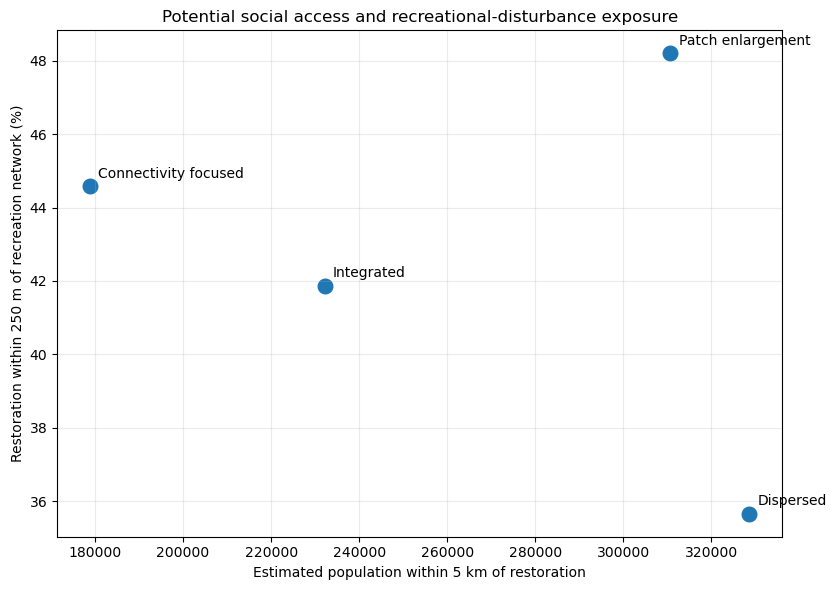


Final outputs saved:
- C:\Users\smit1\BlackGrouse_2030\outputs\tables\scenario_social_access_recreation_summary.csv
- C:\Users\smit1\BlackGrouse_2030\outputs\figures\scenario_social_access_disturbance_tradeoff.png


In [6]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# Combine population and recreation indicators
# ---------------------------------------------------------

social_recreation_summary = (
    population_accessibility
    .merge(
        recreation_accessibility,
        on="scenario",
        how="inner",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------
# Validate final table
# ---------------------------------------------------------

expected_scenarios = {
    "Dispersed",
    "Patch enlargement",
    "Connectivity focused",
    "Integrated",
}

if set(social_recreation_summary["scenario"]) != expected_scenarios:
    raise ValueError(
        "The final table does not contain the expected four scenarios."
    )

if social_recreation_summary.isna().any().any():
    missing_columns = (
        social_recreation_summary
        .columns[
            social_recreation_summary.isna().any()
        ]
        .tolist()
    )

    raise ValueError(
        "Missing values found in: "
        f"{missing_columns}"
    )


# ---------------------------------------------------------
# Create transparent indicator rankings
# ---------------------------------------------------------

social_recreation_summary[
    "population_access_rank"
] = (
    social_recreation_summary[
        "population_within_5km_estimate"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

social_recreation_summary[
    "population_distance_rank"
] = (
    social_recreation_summary[
        "population_weighted_mean_distance_m"
    ]
    .rank(
        ascending=True,
        method="min",
    )
    .astype(int)
)

social_recreation_summary[
    "network_access_rank"
] = (
    social_recreation_summary[
        "restoration_within_500m_percent"
    ]
    .rank(
        ascending=False,
        method="min",
    )
    .astype(int)
)

# Higher exposure within 250 m represents greater
# potential recreational-disturbance pressure.
social_recreation_summary[
    "lowest_disturbance_rank"
] = (
    social_recreation_summary[
        "restoration_within_250m_percent"
    ]
    .rank(
        ascending=True,
        method="min",
    )
    .astype(int)
)


# ---------------------------------------------------------
# Select final Notebook 11 indicators
# ---------------------------------------------------------

final_social_indicators = social_recreation_summary[
    [
        "scenario",
        "population_within_2km_estimate",
        "population_within_5km_estimate",
        "population_within_10km_estimate",
        "population_weighted_mean_distance_m",
        "restoration_within_250m_percent",
        "restoration_within_500m_percent",
        "restoration_within_1000m_percent",
        "potential_parking_access_within_500m",
        "potential_parking_access_within_1000m",
        "population_access_rank",
        "population_distance_rank",
        "network_access_rank",
        "lowest_disturbance_rank",
    ]
].copy()


# ---------------------------------------------------------
# Save final Notebook 11 table
# ---------------------------------------------------------

FINAL_SOCIAL_TABLE_PATH = (
    TABLES_DIR
    / "scenario_social_access_recreation_summary.csv"
)

final_social_indicators.to_csv(
    FINAL_SOCIAL_TABLE_PATH,
    index=False,
)


print("Notebook 11 final validation passed.")

display(
    final_social_indicators.sort_values(
        "population_access_rank"
    )
)


# ---------------------------------------------------------
# Create portfolio scatter plot
# ---------------------------------------------------------

FIGURES_DIR = (
    PROJECT_DIR
    / "outputs"
    / "figures"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

fig, ax = plt.subplots(figsize=(8.5, 6))

ax.scatter(
    final_social_indicators[
        "population_within_5km_estimate"
    ],
    final_social_indicators[
        "restoration_within_250m_percent"
    ],
    s=110,
)

for _, row in final_social_indicators.iterrows():

    ax.annotate(
        row["scenario"],
        (
            row[
                "population_within_5km_estimate"
            ],
            row[
                "restoration_within_250m_percent"
            ],
        ),
        xytext=(6, 6),
        textcoords="offset points",
    )

ax.set_xlabel(
    "Estimated population within 5 km of restoration"
)

ax.set_ylabel(
    "Restoration within 250 m of recreation network (%)"
)

ax.set_title(
    "Potential social access and recreational-disturbance exposure"
)

ax.grid(alpha=0.25)

plt.tight_layout()

SOCIAL_FIGURE_PATH = (
    FIGURES_DIR
    / "scenario_social_access_disturbance_tradeoff.png"
)

plt.savefig(
    SOCIAL_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()


print("\nFinal outputs saved:")
print(f"- {FINAL_SOCIAL_TABLE_PATH}")
print(f"- {SOCIAL_FIGURE_PATH}")